In [1]:
import sqlite3 as sql
from sqlite3 import Connection 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:/Users/aksha/Loan_default_dataset/data/loan_dataset_20000.csv')

In [3]:
# Connect to SQLite database (or create it if it doesn't exist)
connection = sql.connect("loan_dataset.db")
cursor = connection.cursor()

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,loan_purpose,interest_rate,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,Car,13.39,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,Debt consolidation,17.81,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,Business,9.53,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,Other,7.99,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,Car,15.20,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [6]:
df['Loan_ID'] = df.index

In [7]:
demographics = df[['Loan_ID', 'age', 'gender', 'marital_status', 'education_level']]

In [8]:
financial_data = df[['Loan_ID', 'annual_income', 'monthly_income', 
                     'employment_status', 'debt_to_income_ratio', 'credit_score']]

In [9]:
loan_info = df[['Loan_ID', 'loan_amount', 'loan_purpose', 'interest_rate',
                'loan_term', 'installment', 'grade_subgrade']]

In [10]:
credit_history = df[['Loan_ID', 'num_of_open_accounts', 'total_credit_limit', 'current_balance',
                     'delinquency_history', 'public_records', 'num_of_delinquencies']]

In [11]:
target_data = df[['Loan_ID', 'loan_paid_back']]

In [12]:
demographics.to_sql(name='demographics', con=connection, if_exists='replace', index=False)

20000

In [13]:
query = "Select * from demographics where gender='Male'"

In [14]:
result = pd.read_sql_query(query, connection)
result.head()

,Loan_ID,age,gender,marital_status,education_level
0,0,59,Male,Married,Master's
1,5,28,Male,Single,High School
2,6,41,Male,Single,Bachelor's
3,12,44,Male,Single,Master's
4,16,44,Male,Widowed,Master's


In [15]:
query1 = 'Select gender, MAX(age) as max_age, MIN(age) as min_age from demographics group by gender'

In [16]:
result = pd.read_sql_query(query1, connection)
result.head()

,gender,max_age,min_age
0,Female,75,21
1,Male,75,21
2,Other,75,21


In [17]:
query2 = 'Select * from demographics group by gender having age >= MAX(age)'
result = pd.read_sql_query(query2, connection)
result.head()

,Loan_ID,age,gender,marital_status,education_level
0,136,75,Female,Single,High School
1,41,75,Male,Single,Master's
2,586,75,Other,Married,High School


In [18]:
financial_data.to_sql(name='financial_data', con=connection, if_exists='replace', index=False)

20000

In [19]:
credit_history.to_sql(name='credit_history', con=connection, if_exists='replace', index=False)

20000

In [20]:
loan_info.to_sql(name='loan_info', con=connection, if_exists='replace', index=False)

20000

In [21]:
target_data.to_sql(name='target_data', con=connection, if_exists='replace', index=False)

20000

In [22]:
query3 = '''Select a.*, b.*, c.*, d.*, e.* 
            from demographics as a 
            join financial_data as b 
            on a.Loan_ID = b.Loan_ID
            join credit_history as c
            on a.Loan_ID = c.Loan_ID
            join loan_info as d
            on a.Loan_ID = d.Loan_ID
            join target_data as e
            on a.Loan_ID = e.Loan_ID'''

In [23]:
data = pd.read_sql_query(query3, connection)

In [24]:
data.head()

,Loan_ID,age,gender,marital_status,education_level,Loan_ID,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,Loan_ID,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,Loan_ID,loan_amount,loan_purpose,interest_rate,loan_term,installment,grade_subgrade,Loan_ID,loan_paid_back
0,0,59,Male,Married,Master's,0,24240.19,2020.02,Employed,0.074,743,0,7,40833.47,24302.07,1,0,1,0,17173.72,Car,13.39,36,581.88,B5,0,1
1,1,72,Female,Married,Bachelor's,1,20172.98,1681.08,Employed,0.219,531,1,5,27968.01,10803.01,1,0,3,1,22663.89,Debt consolidation,17.81,60,573.17,F1,1,1
2,2,49,Female,Single,High School,2,26181.80,2181.82,Employed,0.234,779,2,2,15502.25,4505.44,0,0,0,2,3631.36,Business,9.53,60,76.32,B4,2,1
3,3,35,Female,Single,High School,3,11873.84,989.49,Employed,0.264,809,3,7,18157.79,5525.63,4,0,5,3,14939.23,Other,7.99,36,468.07,A5,3,1
4,4,63,Other,Single,Other,4,25326.44,2110.54,Employed,0.260,663,4,1,17467.56,3593.91,2,0,2,4,16551.71,Car,15.20,60,395.50,D5,4,1


In [25]:
data = data.loc[:, ~data.columns.duplicated()]

In [26]:
data.head()

,Loan_ID,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_amount,loan_purpose,interest_rate,loan_term,installment,grade_subgrade,loan_paid_back
0,0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,7,40833.47,24302.07,1,0,1,17173.72,Car,13.39,36,581.88,B5,1
1,1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,5,27968.01,10803.01,1,0,3,22663.89,Debt consolidation,17.81,60,573.17,F1,1
2,2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,2,15502.25,4505.44,0,0,0,3631.36,Business,9.53,60,76.32,B4,1
3,3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,7,18157.79,5525.63,4,0,5,14939.23,Other,7.99,36,468.07,A5,1
4,4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,1,17467.56,3593.91,2,0,2,16551.71,Car,15.20,60,395.50,D5,1


In [27]:
data['loan_paid_back'] = 1 - data['loan_paid_back']

In [28]:
data['loan_paid_back'].value_counts()

loan_paid_back
0    15998
1     4002
Name: count, dtype: int64

In [29]:
data['loan_paid_back'].value_counts(normalize=True)

loan_paid_back
0    0.7999
1    0.2001
Name: proportion, dtype: float64

In [30]:
data['loan_paid_back'].value_counts(normalize=True)*100

loan_paid_back
0    79.99
1    20.01
Name: proportion, dtype: float64

In [31]:
data = data.rename(columns={'loan_paid_back':'loan_default'})

In [32]:
data['Loan Paid/Defaulted'] = data['loan_default'].map({0:'paid', 1:'default'})

In [33]:
num_cols = data.select_dtypes(exclude='object').columns.tolist()
cat_cols = data.select_dtypes(include='object').columns.tolist()

In [34]:
num_cols.remove('Loan_ID')

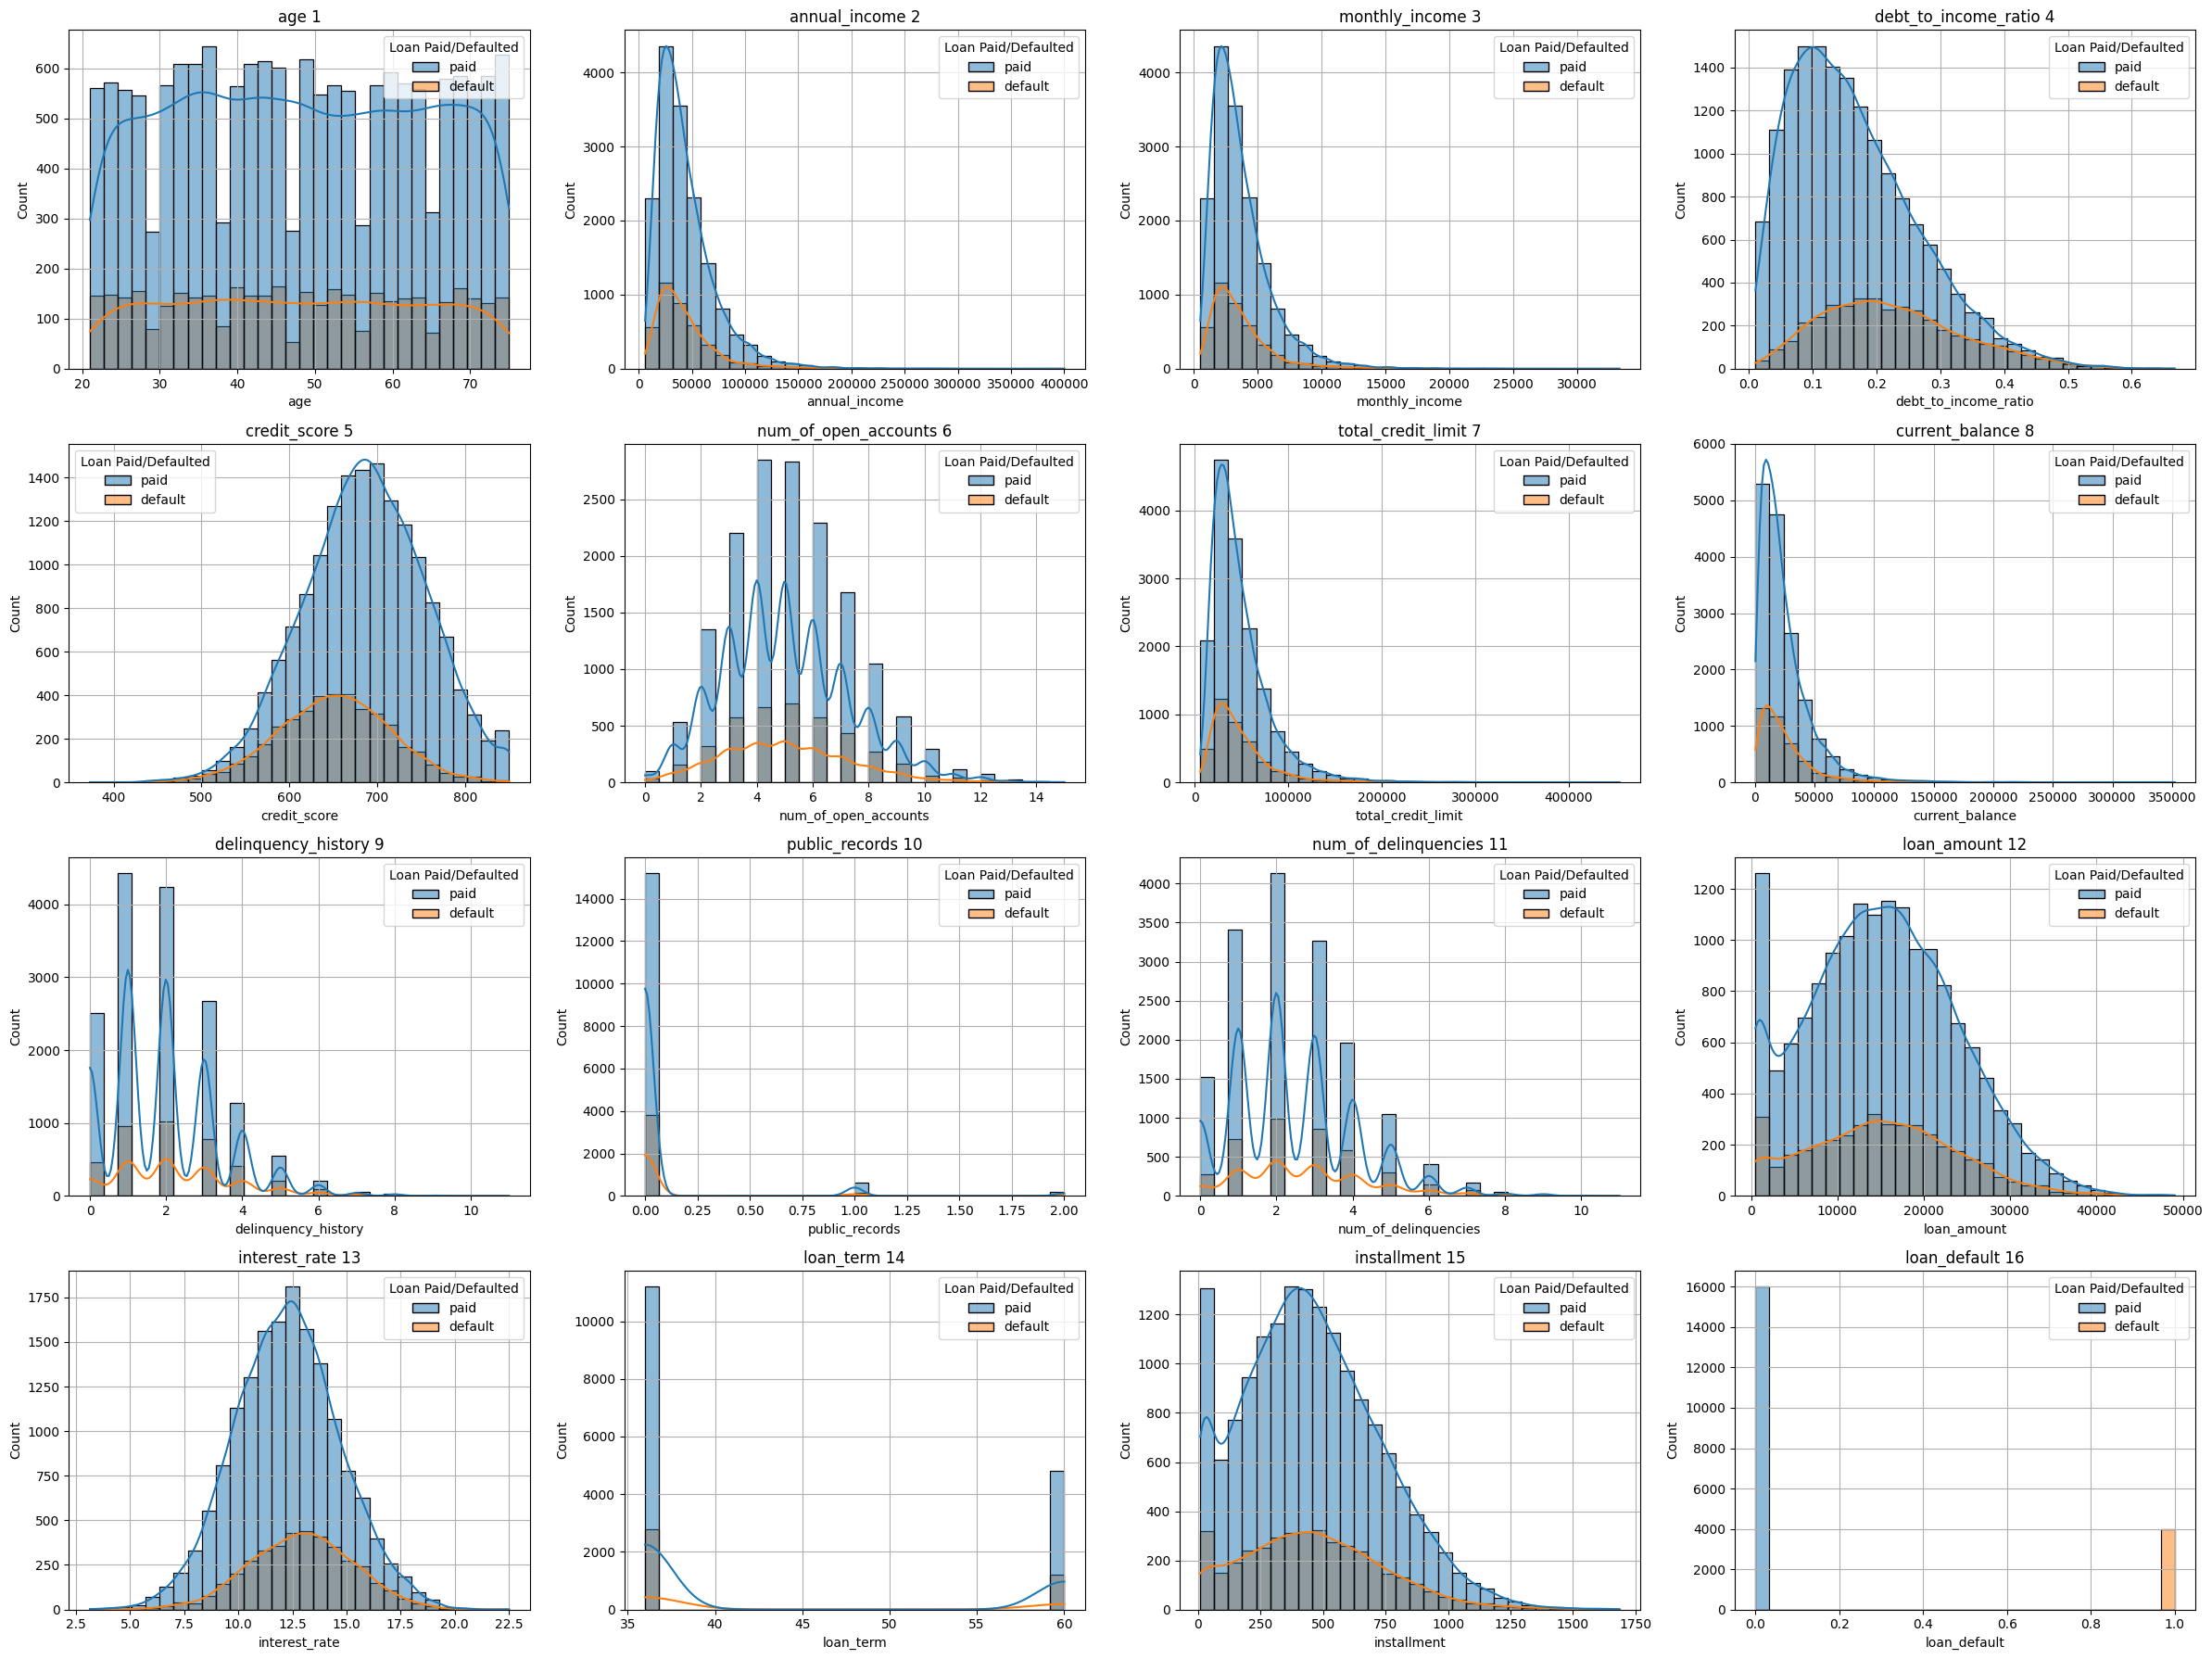

In [35]:
fig, axes = plt.subplots(4, 4, figsize=(24, 18))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, col in enumerate(num_cols):
    sns.histplot(
        data=data,  # combine features + target
        x=col,
        bins=30,
        kde=True,
        hue="Loan Paid/Defaulted",
        ax=axes[i]
    )
    axes[i].set_title(f"{col} {i+1}")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

<Figure size 2500x2000 with 0 Axes>

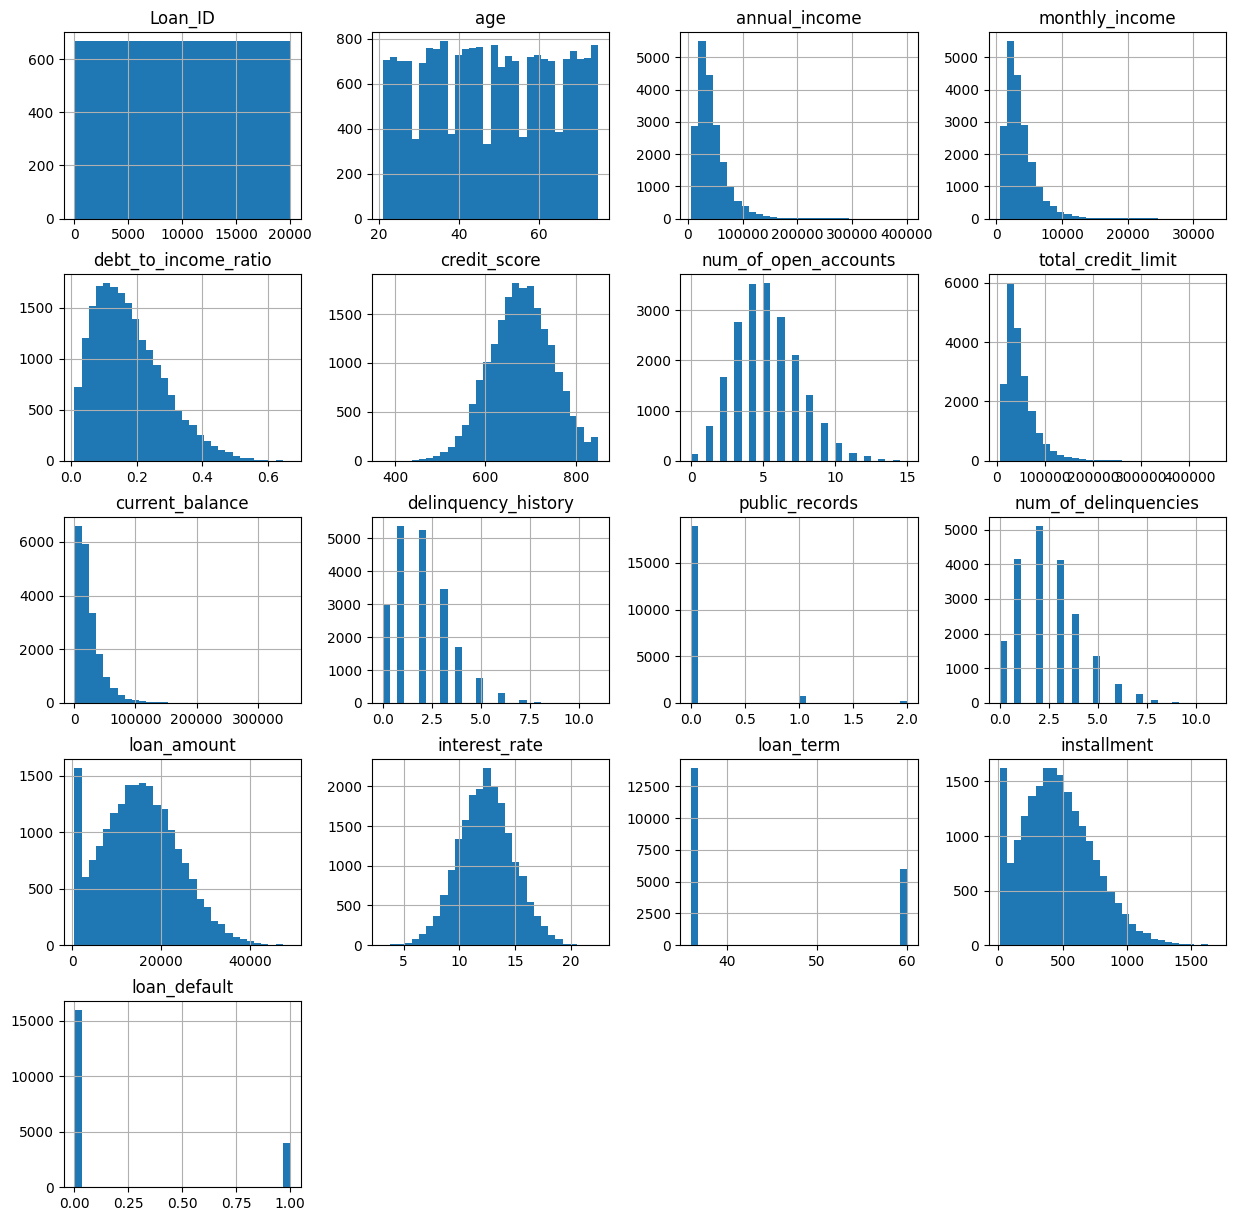

In [36]:
plt.figure(figsize=(25, 20))
data.hist(figsize=(15, 15), bins=30)
plt.show()

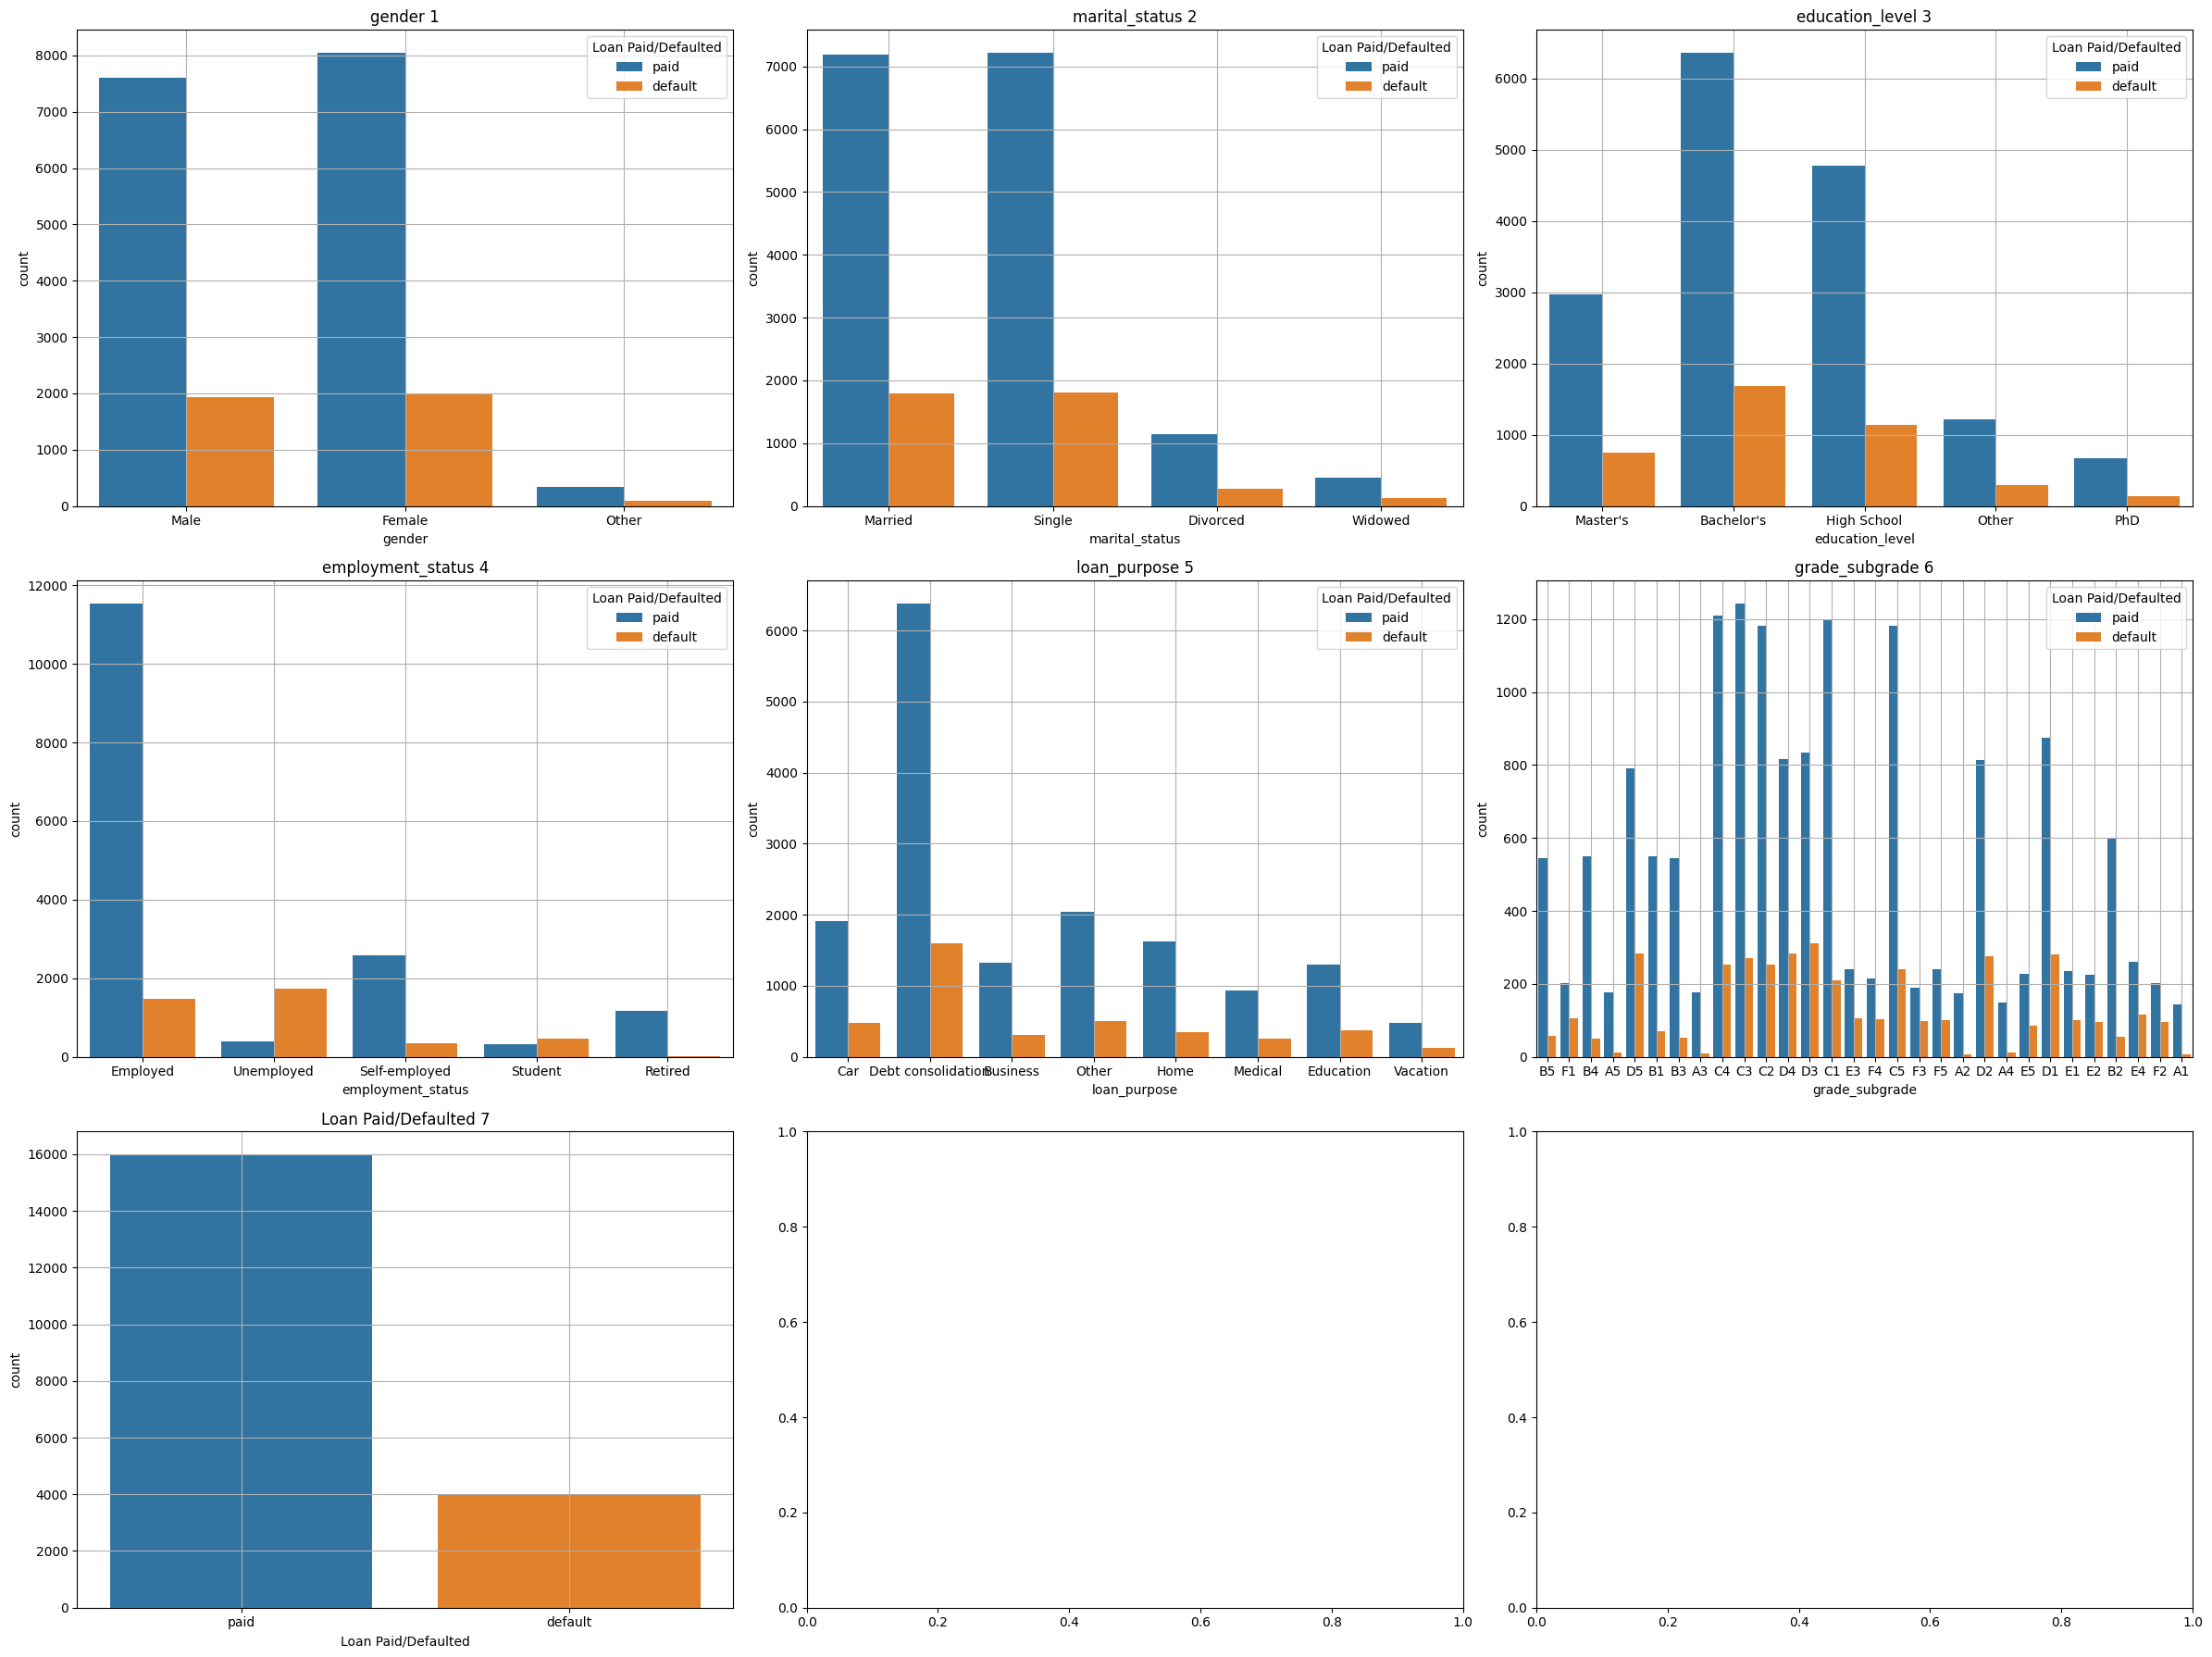

In [37]:
fig, axes = plt.subplots(3, 3, figsize=(24, 18))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=data,  # combine features + target
        x=col,
        hue='Loan Paid/Defaulted',
        ax=axes[i]
    )
    axes[i].set_title(f"{col} {i+1}")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [38]:
data.describe()

,Loan_ID,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_amount,interest_rate,loan_term,installment,loan_default
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000
mean,9999.500000,48.027000,43549.637765,3629.136466,0.177019,679.25695,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,15129.300909,12.400627,43.22280,455.625794,0.200100
std,5773.647028,15.829352,28668.579671,2389.048326,0.105059,69.63858,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,8605.405513,2.442729,11.00838,274.622125,0.400085
min,0.000000,21.000000,6000.000000,500.000000,0.010000,373.00000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,500.000000,3.140000,36.00000,9.430000,0.000000
25%,4999.750000,35.000000,24260.752500,2021.730000,0.096000,632.00000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,8852.695000,10.740000,36.00000,253.910000,0.000000
50%,9999.500000,48.000000,36585.260000,3048.770000,0.160000,680.00000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,14946.170000,12.400000,36.00000,435.595000,0.000000
75%,14999.250000,62.000000,54677.917500,4556.495000,0.241000,727.00000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,20998.867500,14.002500,60.00000,633.595000,0.000000
max,19999.000000,75.000000,400000.000000,33333.330000,0.667000,850.00000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,49039.690000,22.510000,60.00000,1685.400000,1.000000


In [39]:
for col in num_cols:
    Q1, Q3 = np.percentile(data[col], [25, 75])
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((data[col] < lower_bound) | (data[col] > upper_bound)).astype(int)
    print(f"Outliers for {col}: {outliers.sum()}")

Outliers for age: 0
Outliers for annual_income: 924
Outliers for monthly_income: 924
Outliers for debt_to_income_ratio: 262
Outliers for credit_score: 74
Outliers for num_of_open_accounts: 283
Outliers for total_credit_limit: 950
Outliers for current_balance: 1015
Outliers for delinquency_history: 142
Outliers for public_records: 1003
Outliers for num_of_delinquencies: 364
Outliers for loan_amount: 76
Outliers for interest_rate: 141
Outliers for loan_term: 0
Outliers for installment: 150
Outliers for loan_default: 4002


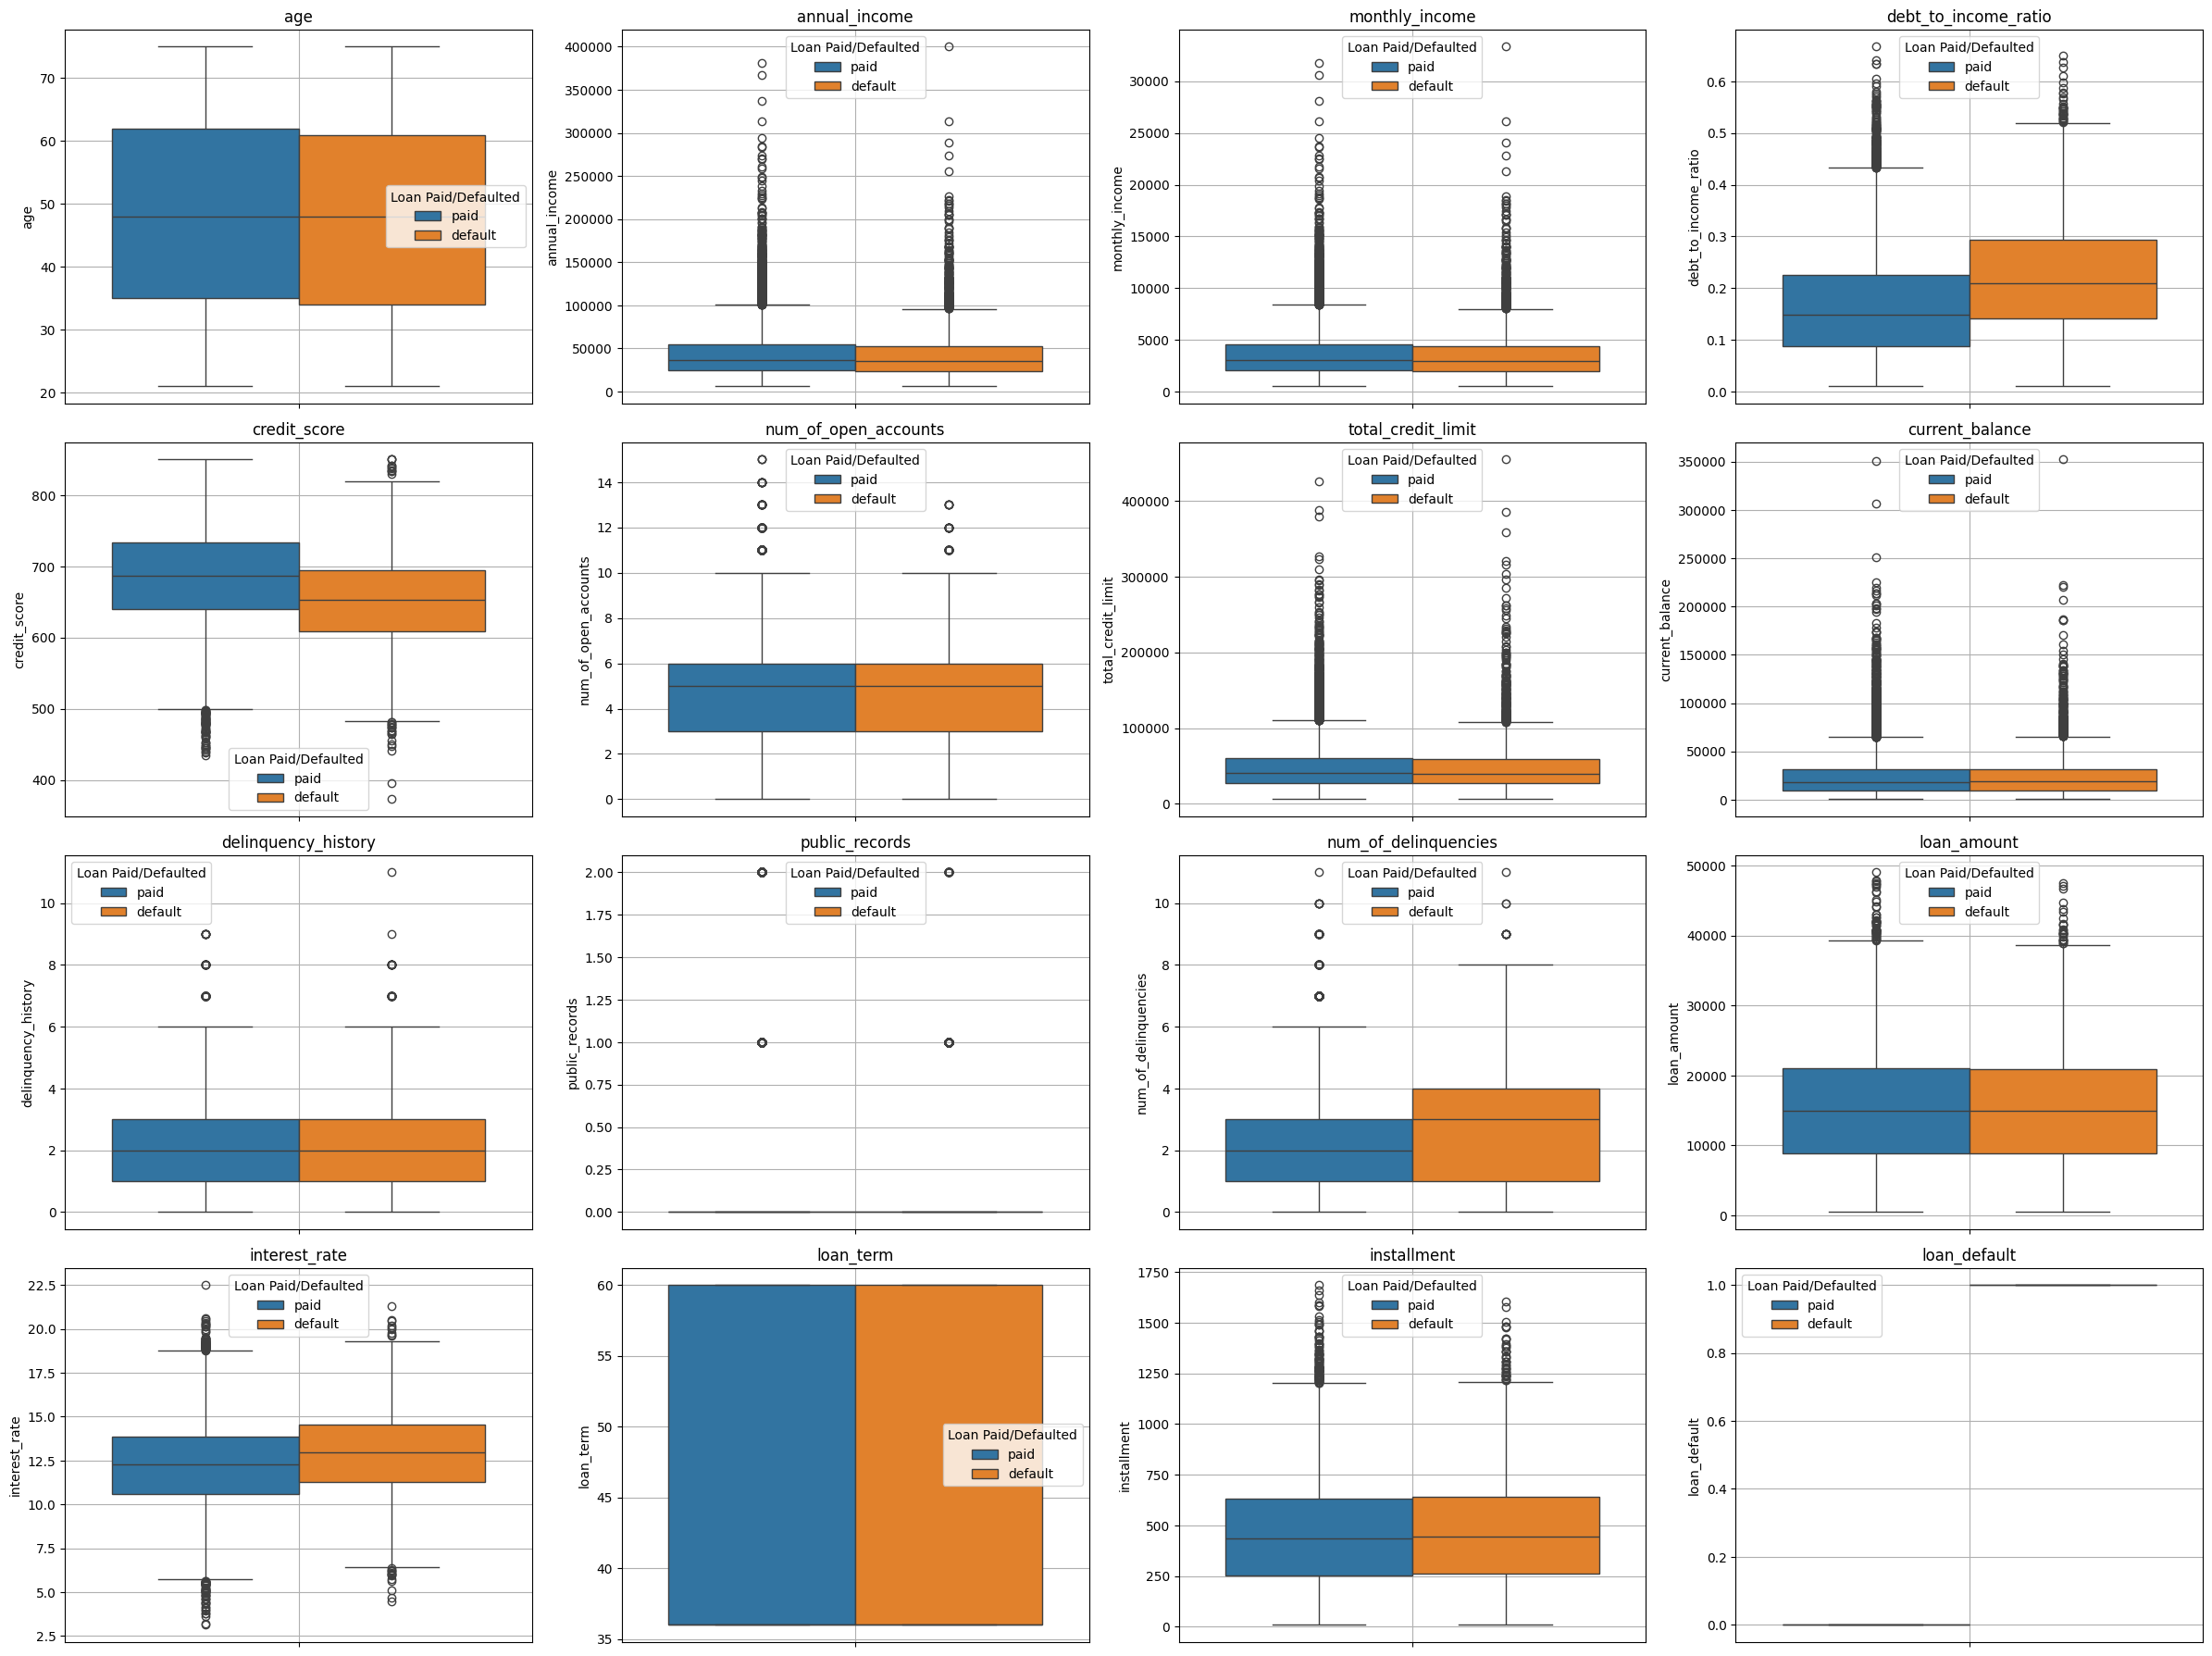

In [40]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(24, 18))  # 2 rows, 3 columns
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, col in enumerate(num_cols):
    sns.boxplot(data, y=col, ax=axes[i], hue='Loan Paid/Defaulted')
    axes[i].set_title(f"{col}")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [41]:
#demographics, credit_history, financial_data, loan_info, target_data

In [42]:
labels = ['Low', 'Medium', 'High']
data['age_cat'] = pd.qcut(data['age'], q=3, labels=labels)
data['income_cat'] = pd.qcut(data['monthly_income'], q=3, labels=labels)
data['loan_amt_cat'] = pd.qcut(data['loan_amount'], q=3, labels=labels)
data['credit_score_cat'] = pd.qcut(data['credit_score'], q=3, labels=labels)
data['debt_to_income_ratio_cat'] = pd.qcut(data['debt_to_income_ratio'], q=3, labels=labels)
data['total_credit_limit_cat'] = pd.qcut(data['total_credit_limit'], q=3, labels=labels)
data['current_balance_cat'] = pd.qcut(data['current_balance'], q=3, labels=labels)

In [43]:
default_by_age = data.groupby('age_cat')['Loan Paid/Defaulted'].value_counts()

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\3843716708.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_age = data.groupby('age_cat')['Loan Paid/Defaulted'].value_counts()


In [44]:
default_by_income = data.groupby('income_cat')['Loan Paid/Defaulted'].value_counts()

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\3438662810.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_income = data.groupby('income_cat')['Loan Paid/Defaulted'].value_counts()


In [45]:
default_by_loan_amt = data.groupby('loan_amt_cat')['Loan Paid/Defaulted'].value_counts()

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\3740887390.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_loan_amt = data.groupby('loan_amt_cat')['Loan Paid/Defaulted'].value_counts()


In [46]:
default_by_credit_score = data.groupby('credit_score_cat')['Loan Paid/Defaulted'].value_counts()

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\1209602871.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_credit_score = data.groupby('credit_score_cat')['Loan Paid/Defaulted'].value_counts()


In [47]:
default_by_dtir = data.groupby('debt_to_income_ratio_cat')['Loan Paid/Defaulted'].value_counts()

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\257361420.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_dtir = data.groupby('debt_to_income_ratio_cat')['Loan Paid/Defaulted'].value_counts()


In [48]:
default_by_total_credit_limit = data.groupby('total_credit_limit_cat')['Loan Paid/Defaulted'].value_counts()

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\3761115236.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_total_credit_limit = data.groupby('total_credit_limit_cat')['Loan Paid/Defaulted'].value_counts()


In [49]:
default_by_curr_balance = data.groupby('current_balance_cat')['Loan Paid/Defaulted'].value_counts()

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\1468439628.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_curr_balance = data.groupby('current_balance_cat')['Loan Paid/Defaulted'].value_counts()


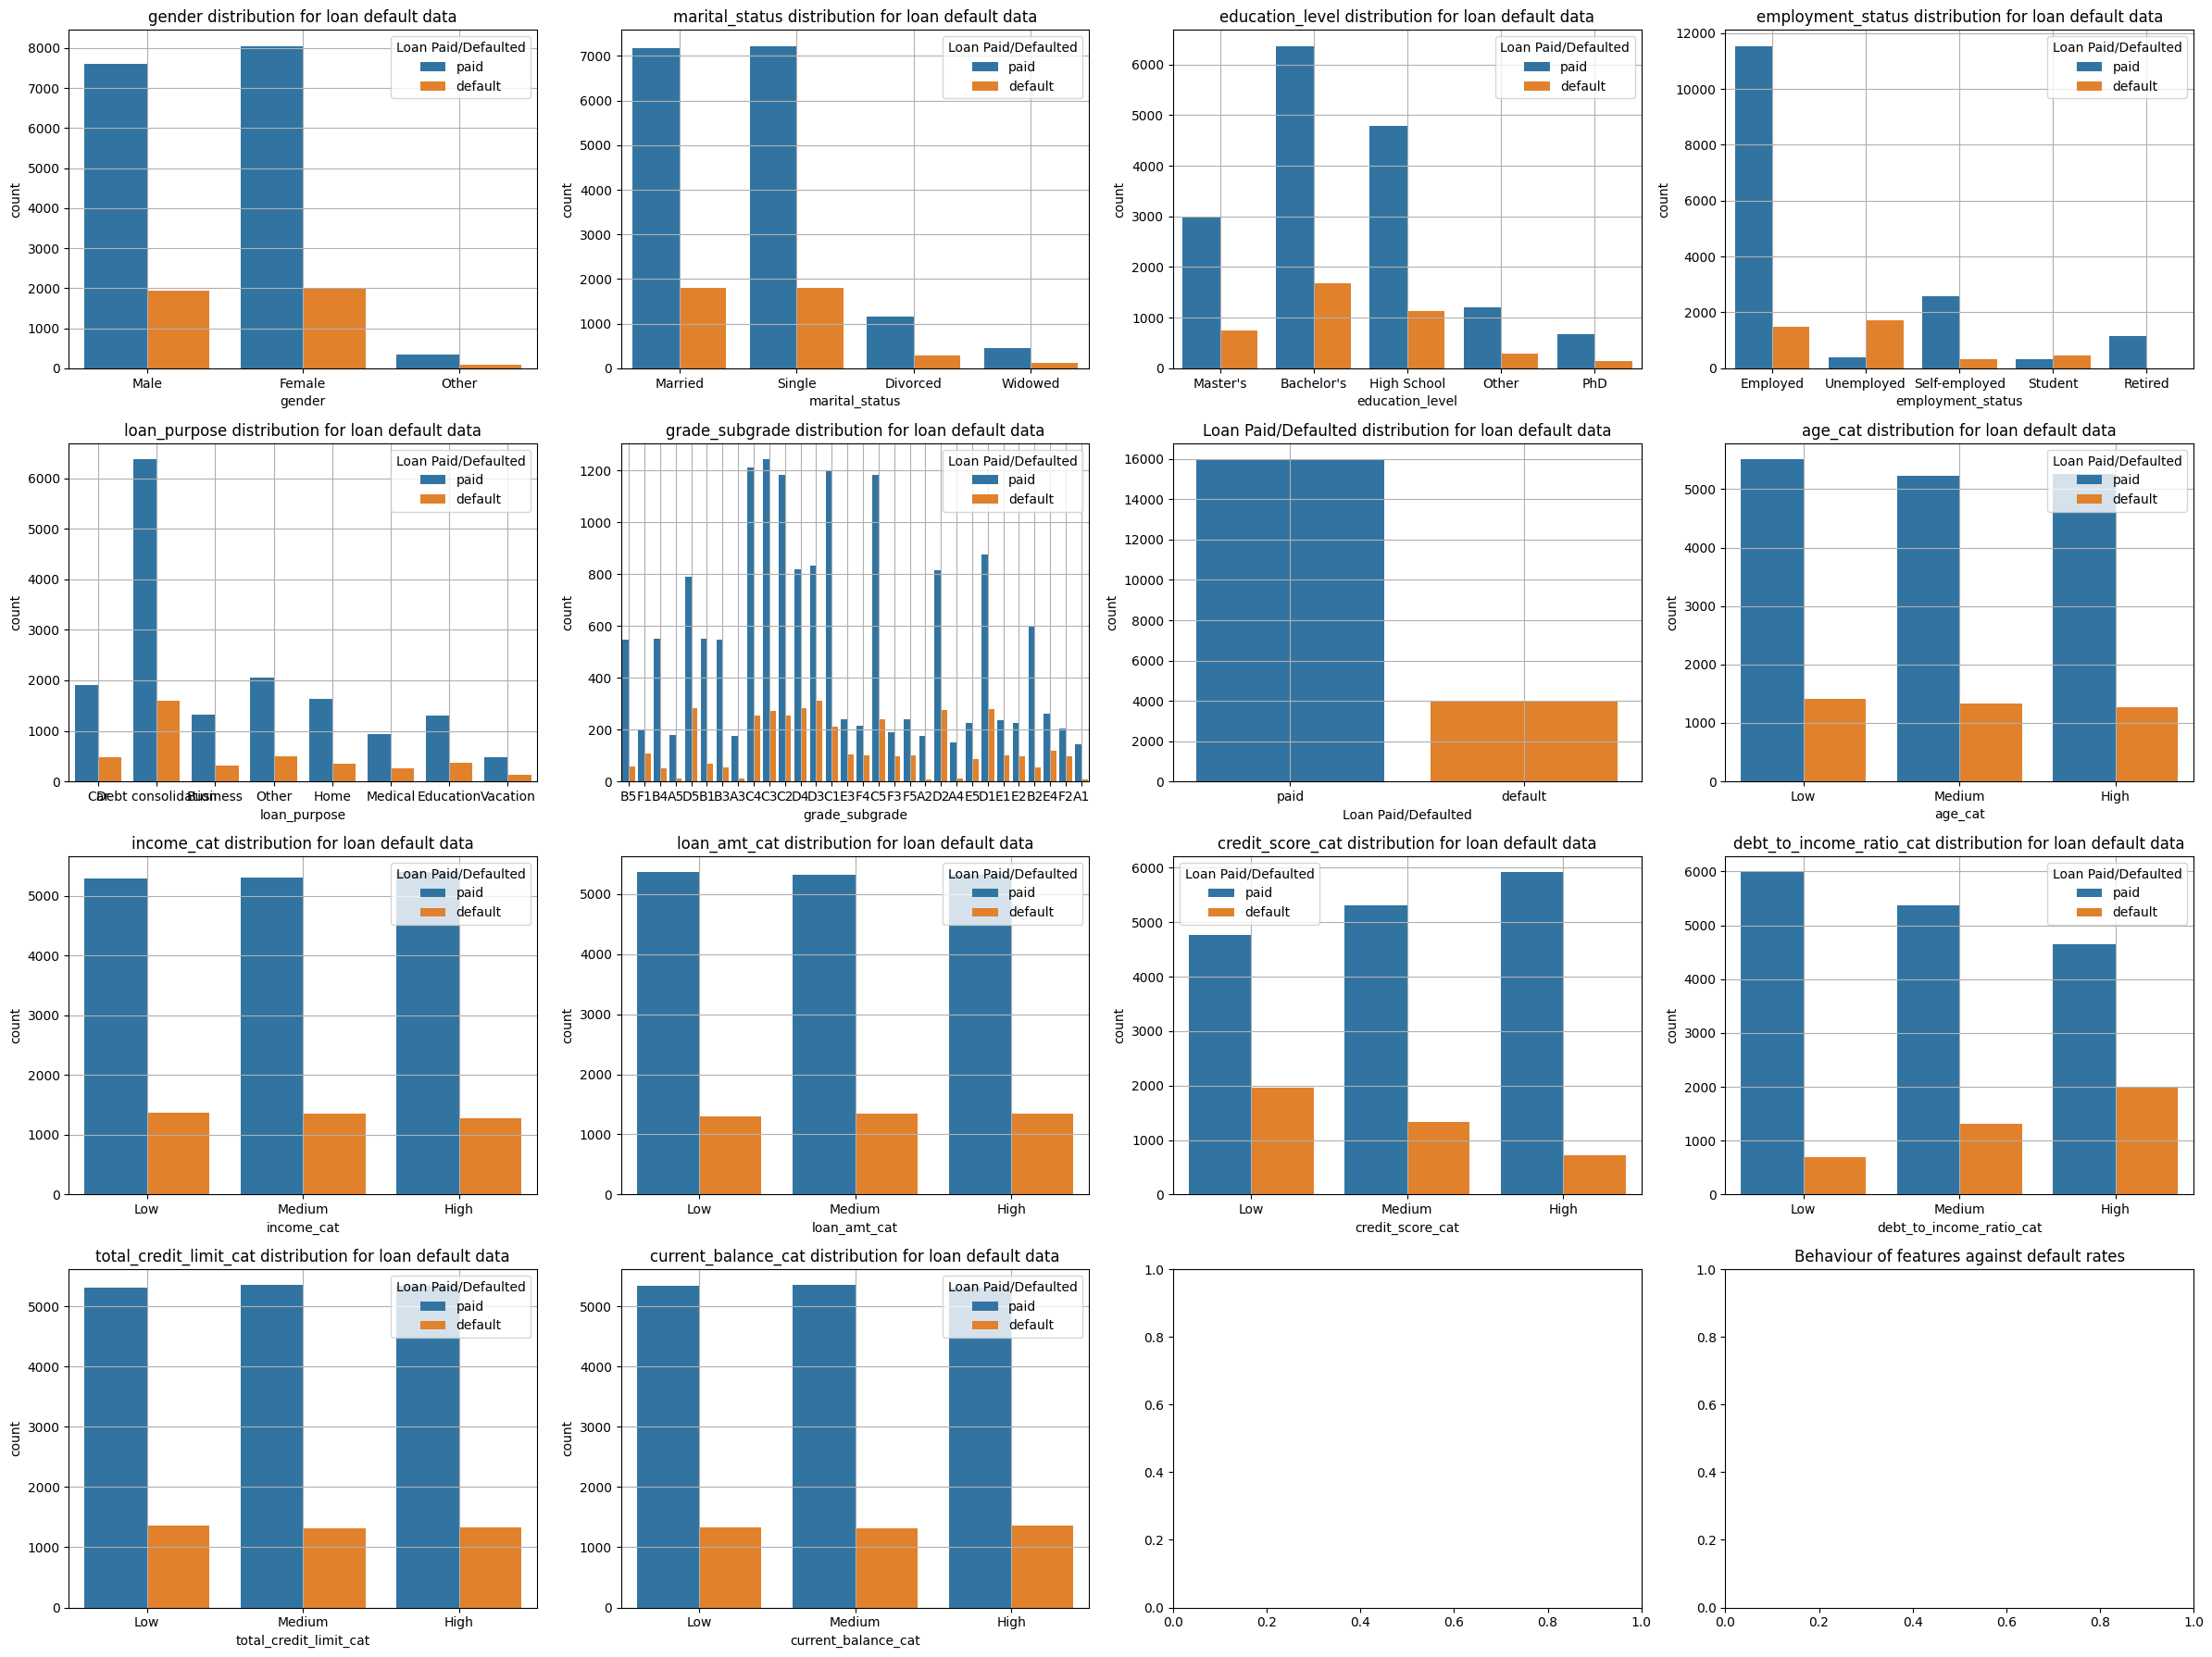

In [50]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(24, 18))  # 2 rows, 3 columns
axes = axes.flatten()  # Flatten to 1D for easy indexing

cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
for i, col in enumerate(cat_cols):
    sns.countplot(data, x=col, ax=axes[i], hue='Loan Paid/Defaulted', )
    axes[i].set_title(f"{col} distribution for loan default data")
    axes[i].grid(True)
plt.title('Behaviour of features against default rates')
plt.tight_layout()
plt.show()

In [51]:
data.groupby('age_cat')['loan_default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\2567000851.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_cat')['loan_default'].mean()*100


age_cat
Low       20.320856
Medium    20.295597
High      19.392452
Name: loan_default, dtype: float64

In [52]:
data.groupby('income_cat')['loan_default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\175998260.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('income_cat')['loan_default'].mean()*100


income_cat
Low       20.578971
Medium    20.387039
High      19.064047
Name: loan_default, dtype: float64

In [53]:
data.groupby('credit_score_cat')['loan_default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\4242324997.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('credit_score_cat')['loan_default'].mean()*100


credit_score_cat
Low       29.109029
Medium    20.021075
High      10.777811
Name: loan_default, dtype: float64

In [54]:
data.groupby('current_balance_cat')['loan_default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\486596073.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('current_balance_cat')['loan_default'].mean()*100


current_balance_cat
Low       19.949003
Medium    19.771977
High      20.308985
Name: loan_default, dtype: float64

In [55]:
data.groupby('debt_to_income_ratio_cat')['loan_default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\2326927434.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('debt_to_income_ratio_cat')['loan_default'].mean()*100


debt_to_income_ratio_cat
Low       10.283316
Medium    19.709668
High      30.073717
Name: loan_default, dtype: float64

In [56]:
data.groupby('delinquency_history')['loan_default'].mean()*100

delinquency_history
0      15.583978
1      17.881655
2      19.517752
3      22.690531
4      24.513848
5      27.189542
6      30.033003
7      35.869565
8      26.829268
9      12.500000
11    100.000000
Name: loan_default, dtype: float64

In [57]:
data.groupby('loan_amt_cat')['loan_default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\916858106.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('loan_amt_cat')['loan_default'].mean()*100


loan_amt_cat
Low       19.544023
Medium    20.252025
High      20.233988
Name: loan_default, dtype: float64

In [58]:
data.groupby('education_level')['loan_default'].mean()*100

education_level
Bachelor's     20.870106
High School    19.192431
Master's       20.220193
Other          19.628647
PhD            17.164179
Name: loan_default, dtype: float64

In [59]:
data.groupby('total_credit_limit_cat')['loan_default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\3475387743.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('total_credit_limit_cat')['loan_default'].mean()*100


total_credit_limit_cat
Low       20.323984
Medium    19.786979
High      19.919004
Name: loan_default, dtype: float64

In [60]:
data.groupby('loan_purpose')['loan_default'].mean()*100

loan_purpose
Business              19.091467
Car                   20.167364
Debt consolidation    20.060143
Education             22.208955
Home                  17.596349
Medical               21.739130
Other                 19.725490
Vacation              20.757825
Name: loan_default, dtype: float64

In [61]:
data.groupby('public_records')['loan_default'].mean()*100

public_records
0    20.018950
1    20.519481
2    17.596567
Name: loan_default, dtype: float64

In [62]:
data.groupby('employment_status')['loan_default'].mean()*100

employment_status
Employed         11.301607
Retired           0.510204
Self-employed    11.426616
Student          59.282971
Unemployed       81.826787
Name: loan_default, dtype: float64

In [63]:
labels = ['Low', 'Medium', 'High']
data['interest_rate_cat'] = pd.qcut(data['interest_rate'], q=3, labels=labels)
data.groupby('interest_rate_cat')['loan_default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\2642615195.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('interest_rate_cat')['loan_default'].mean()*100


interest_rate_cat
Low       15.261345
Medium    19.474313
High      25.335748
Name: loan_default, dtype: float64

In [64]:
labels = ['Low', 'Medium', 'High']
data['installment_cat'] = pd.qcut(data['installment'], q=3, labels=labels)
data.groupby('installment_cat')['loan_default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_5656\3881319298.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('installment_cat')['loan_default'].mean()*100


installment_cat
Low       19.604020
Medium    19.741974
High      20.683966
Name: loan_default, dtype: float64

In [65]:
data.groupby('grade_subgrade')['loan_default'].mean()*100

grade_subgrade
A1     4.000000
A2     3.846154
A3     5.376344
A4     7.453416
A5     6.315789
B1    11.129032
B2     8.409786
B3     8.848080
B4     8.193980
B5     9.602649
C1    14.964539
C2    17.688022
C3    17.899604
C4    17.293233
C5    16.877637
D1    24.242424
D2    25.297892
D3    27.225131
D4    25.727273
D5    26.374651
E1    29.970326
E2    29.906542
E3    30.346821
E4    30.952381
E5    27.476038
F1    34.627832
F2    32.107023
F3    34.146341
F4    32.278481
F5    29.411765
Name: loan_default, dtype: float64

In [66]:
X = data.drop(columns=['Loan_ID', 'gender'])

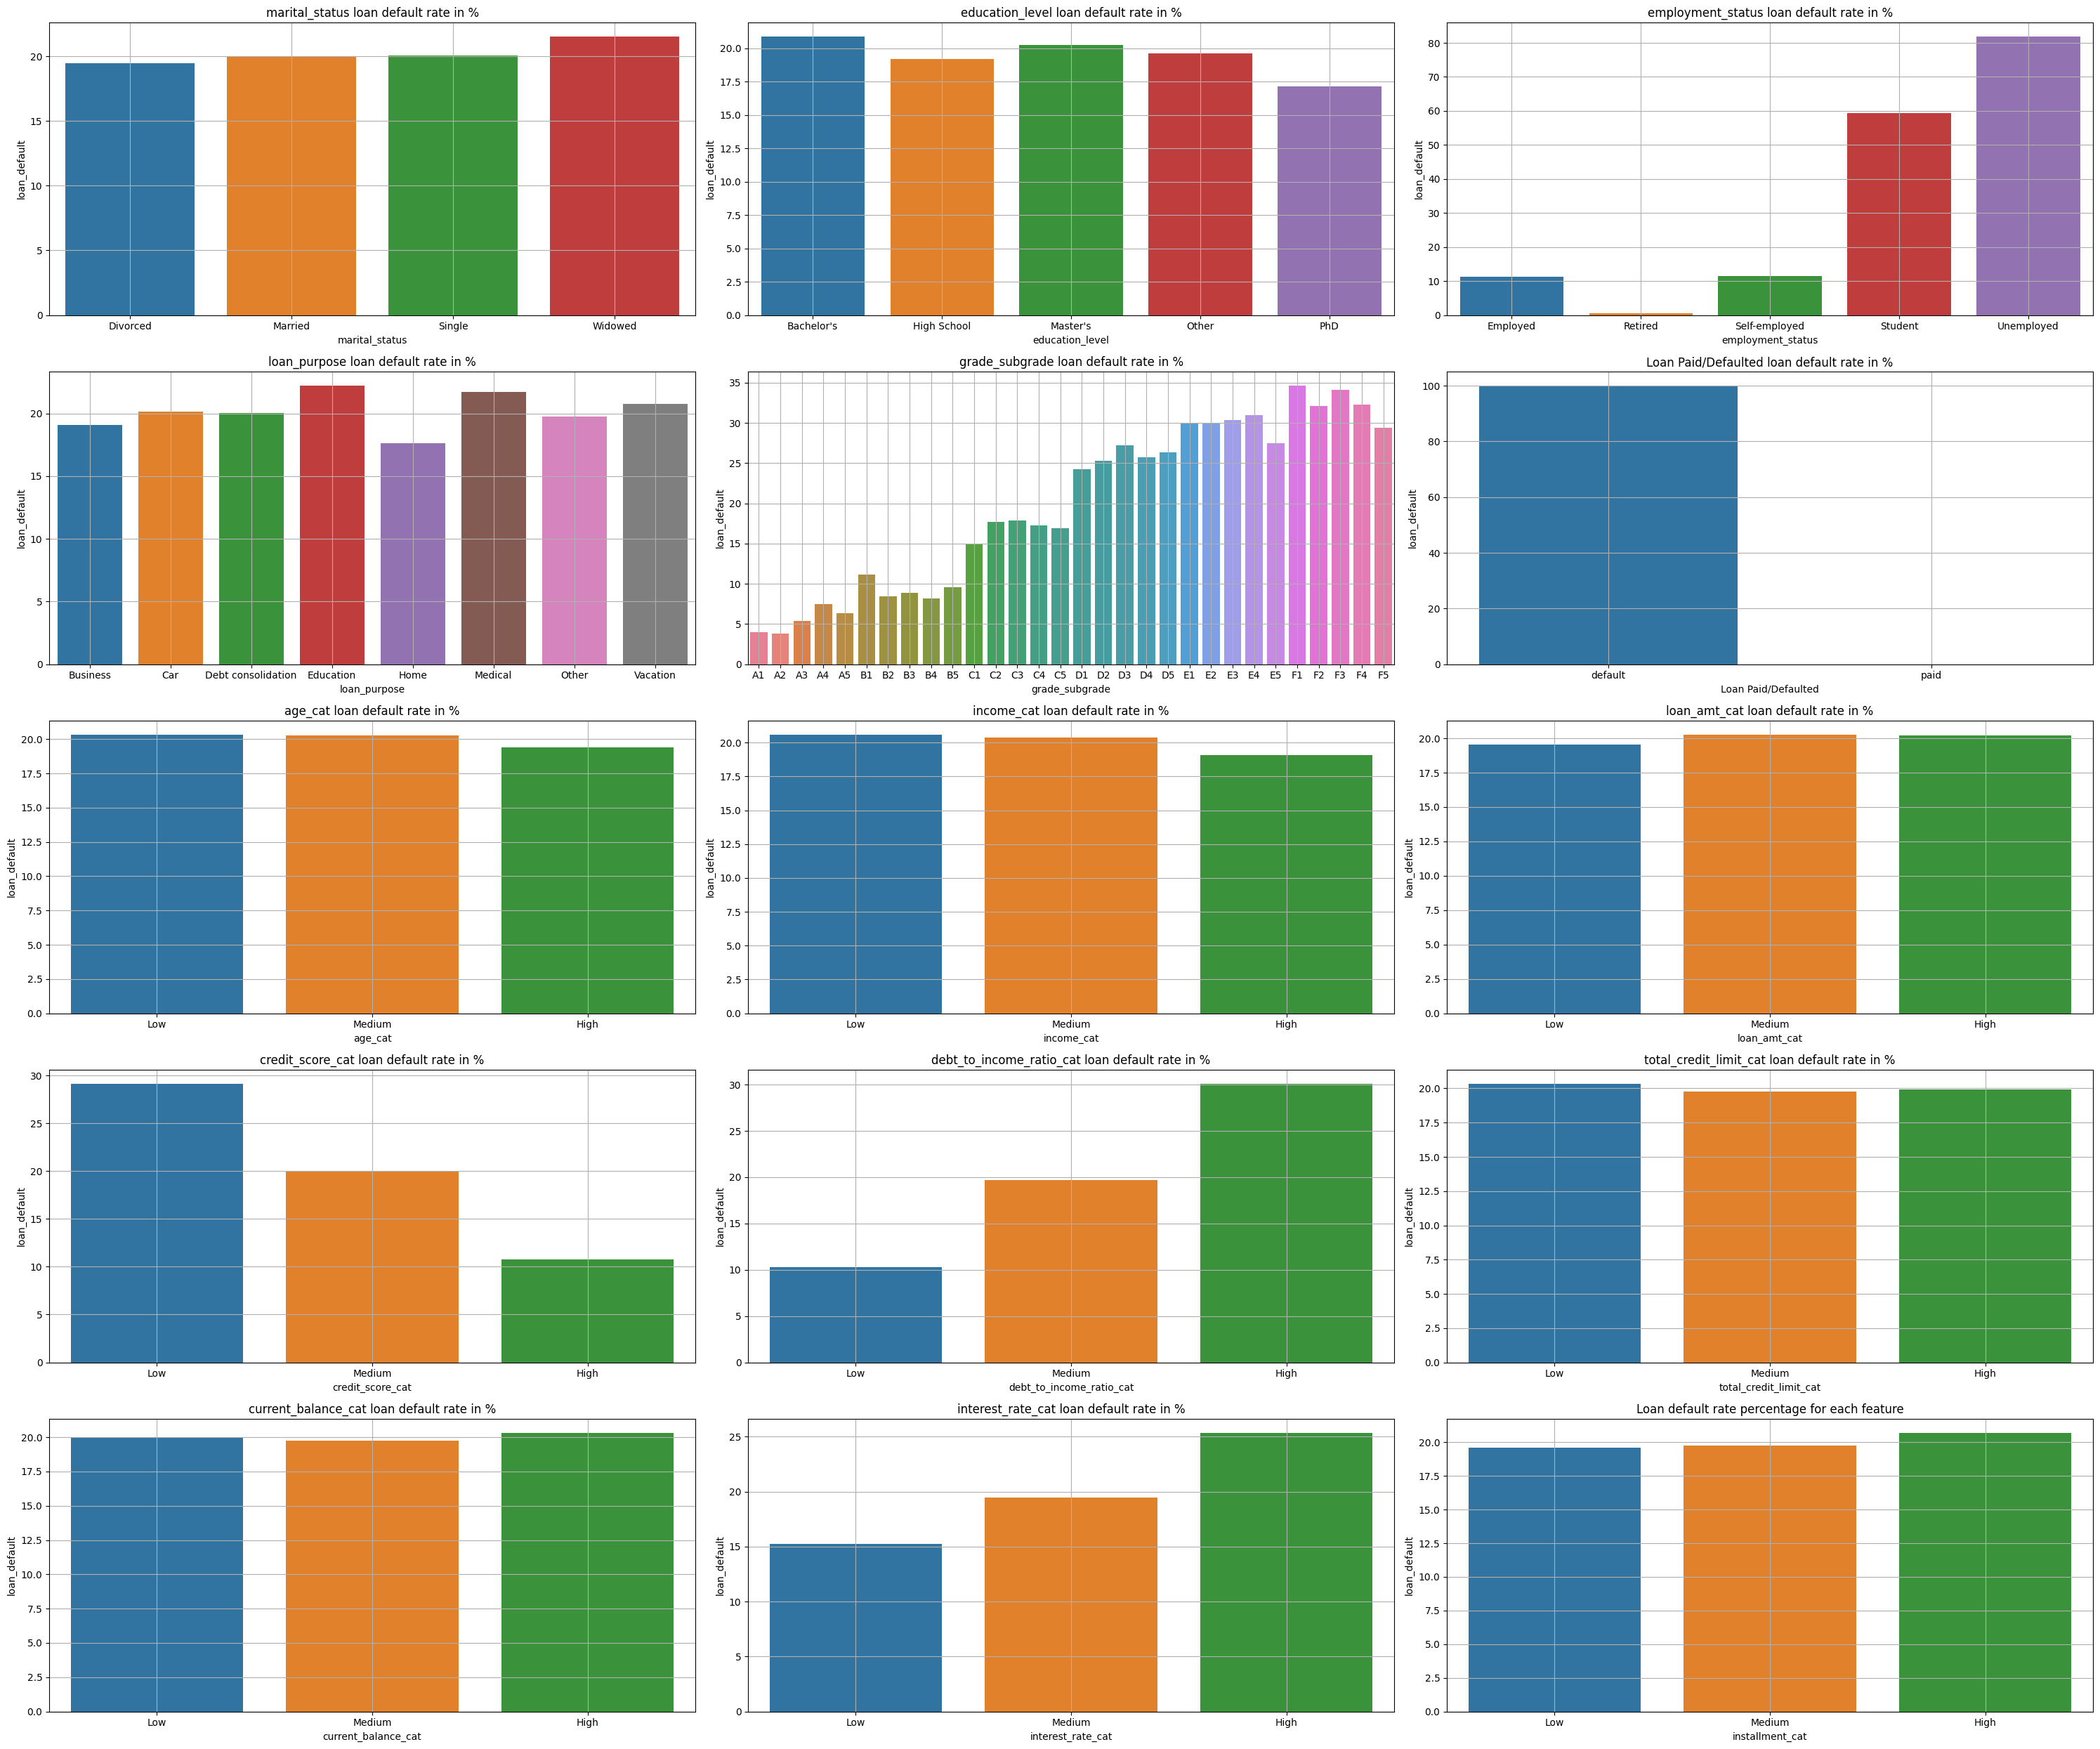

In [67]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(30, 25))  # 2 rows, 3 columns
axes = axes.flatten()  # Flatten to 1D for easy indexing
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for i, col in enumerate(cat_cols):
    feature = data.groupby(col, observed=True)['loan_default'].mean().reset_index()
    feature['loan_default'] *= 100  # convert to percentage
    sns.barplot(feature, x=col, ax=axes[i], y='loan_default', hue=col)
    axes[i].set_title(f"{col} loan default rate in %")
    axes[i].grid(True)
plt.title('Loan default rate percentage for each feature')
plt.savefig('C:/Users/aksha/Loan_default_dataset/data/visualizations.png')
plt.tight_layout()
plt.show()

In [68]:
data['grade_subgrade'].unique()

array(['B5', 'F1', 'B4', 'A5', 'D5', 'B1', 'B3', 'A3', 'C4', 'C3', 'C2',
       'D4', 'D3', 'C1', 'E3', 'F4', 'C5', 'F3', 'F5', 'A2', 'D2', 'A4',
       'E5', 'D1', 'E1', 'E2', 'B2', 'E4', 'F2', 'A1'], dtype=object)